# 02 - Data Collection
Fetch Polymarket probability timeseries and freight index data.

In [17]:
import sys
sys.path.insert(0, "..")
import logging
logging.basicConfig(level=logging.INFO)
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.facecolor'] = 'white'

## Step 1: Load discovered markets

In [18]:
from src.polymarket.market_discovery import load_discovered_markets

markets_df = load_discovered_markets()
print(f'Loaded {len(markets_df)} markets')
markets_df[['market_id', 'title', 'category', 'status']].head(10)

Loaded 35912 markets


,market_id,title,category,status
0,253591,Will Donald Trump win the 2024 US Presidential...,NaN,closed
1,253597,Will Kamala Harris win the 2024 US Presidentia...,NaN,closed
2,511754,Will Donald Trump be inaugurated?,NaN,closed
3,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,NaN,closed
4,253642,Will any other Republican Politician win the 2...,NaN,closed
5,253609,Will Michelle Obama win the 2024 US Presidenti...,NaN,closed
6,538932,Will Zohran Mamdani win the 2025 NYC mayoral e...,NaN,closed
7,253595,Will Robert F. Kennedy Jr. win the 2024 US Pre...,NaN,closed
8,253706,Will Donald Trump win the popular vote in the ...,NaN,closed
9,253641,Will any other Democratic Politician win the 2...,NaN,closed


## Step 2: Fetch Polymarket timeseries

In [19]:
import importlib, datetime
from pathlib import Path
import yaml

# Force-reload the module so the kernel picks up any on-disk edits without
# requiring a full kernel restart. Safe to leave in permanently.
import src.polymarket.timeseries as _ts_mod
importlib.reload(_ts_mod)

from src.polymarket.client import PolymarketClient
from src.polymarket.timeseries import TimeseriesFetcher

PANEL_PATH = Path('../data/processed/timeseries_panel.csv')
FORCE_REFRESH = False  # set True to re-fetch even if panel exists

# Read study-period start from settings so this cell stays in sync with config
with open('../config/settings.yaml') as _f:
    _settings = yaml.safe_load(_f)
STUDY_START = _settings['analysis']['study_period']['start']  # e.g. "2023-01-01"

if PANEL_PATH.exists() and not FORCE_REFRESH:
    panel = pd.read_csv(PANEL_PATH, parse_dates=['date'])
    timeseries = {mid: grp.reset_index(drop=True) for mid, grp in panel.groupby('market_id')}
    print(f'Loaded timeseries panel from cache: {len(timeseries)} markets, {len(panel):,} rows')
    print('Set FORCE_REFRESH=True to re-fetch from the API.')
else:
    # Filter markets before fetching:
    # 1. Only markets with a recognised supply-chain category
    # 2. Only markets created on or after STUDY_START (or with no parseable creation date)
    markets_filtered = markets_df[markets_df['category'].notna()].copy()
    markets_filtered['_created_dt'] = pd.to_datetime(
        markets_filtered['created_at'], errors='coerce', utc=True
    )
    markets_filtered = markets_filtered[
        markets_filtered['_created_dt'].isna() |
        (markets_filtered['_created_dt'] >= STUDY_START)
    ].drop(columns=['_created_dt'])

    print(f'Study start: {STUDY_START}')
    print(f'Filtered: {len(markets_df):,} total → {len(markets_filtered)} markets (categorized, {STUDY_START[:4]}+)')
    print(f'Categories: {markets_filtered["category"].value_counts().to_dict()}')

    # Fetch data from CLOB starting at STUDY_START (reduces payload per market)
    study_start_ts = int(datetime.datetime.fromisoformat(STUDY_START).replace(
        tzinfo=datetime.timezone.utc).timestamp())
    client = PolymarketClient()
    fetcher = TimeseriesFetcher(client)
    timeseries = fetcher.fetch_all(
        markets_filtered,
        start_ts=study_start_ts,
        max_workers=8,
    )
    # Persist combined panel CSV so NB 03 and 04 skip the API entirely
    fetcher.build_panel(timeseries)
    print(f'Fetched {len(timeseries)} markets → panel saved to {PANEL_PATH}')

print(f'Timeseries ready: {len(timeseries)} markets')

INFO:src.polymarket.timeseries:Fetching timeseries for 7119 markets …


Study start: 2023-01-01
Filtered: 35,912 total → 7119 markets (categorized, 2023+)
Categories: {'labor_disruption': 4306, 'tariffs_us_china': 1572, 'iran_hormuz': 918, 'eu_tariffs': 191, 'us_trade_policy': 69, 'red_sea_houthi': 63}


INFO:src.polymarket.timeseries:5790 markets loaded from cache; 1329 require API calls.
INFO:src.polymarket.timeseries:Fetching history for market 508503 (token 21151499090639157023105520573782804187006240987910179362864625151010763665435) …
INFO:src.polymarket.timeseries:Fetching history for market 552064 (token 35165864485131867490876018829378241981100245790382503055069974672337051187204) …
INFO:src.polymarket.timeseries:Fetching history for market 1096589 (token 10001945247466016958890681330895387918419066882066596254381999848917758583889) …
INFO:src.polymarket.timeseries:Fetching history for market 554701 (token 39151492672543965221487457534020868730976246502230960123570360903147707612370) …
INFO:src.polymarket.timeseries:Fetching history for market 1096586 (token 12799381267496135147768698855810031078131966696677797752451254533525682123689) …
INFO:src.polymarket.timeseries:Fetching history for market 528600 (token 95758009727749070198233551272938108795936729777567095937625553412173

Fetched 5790 markets → panel saved to ..\data\processed\timeseries_panel.csv
Timeseries ready: 5790 markets


In [20]:
# Show coverage statistics
coverages = []
for mid, df in timeseries.items():
    if not df.empty:
        coverages.append({
            'market_id': mid,
            'start': df['date'].min(),
            'end': df['date'].max(),
            'n_days': len(df),
            'title': df['market_title'].iloc[0] if 'market_title' in df.columns else mid,
        })
coverage_df = pd.DataFrame(coverages)
print('Data coverage summary:')
coverage_df.describe()

Data coverage summary:


,n_days
count,5790.000000
mean,15.215717
std,29.336215
min,1.000000
25%,2.000000
50%,7.000000
75%,15.000000
max,368.000000


## Step 3: Visualize key Polymarket timeseries

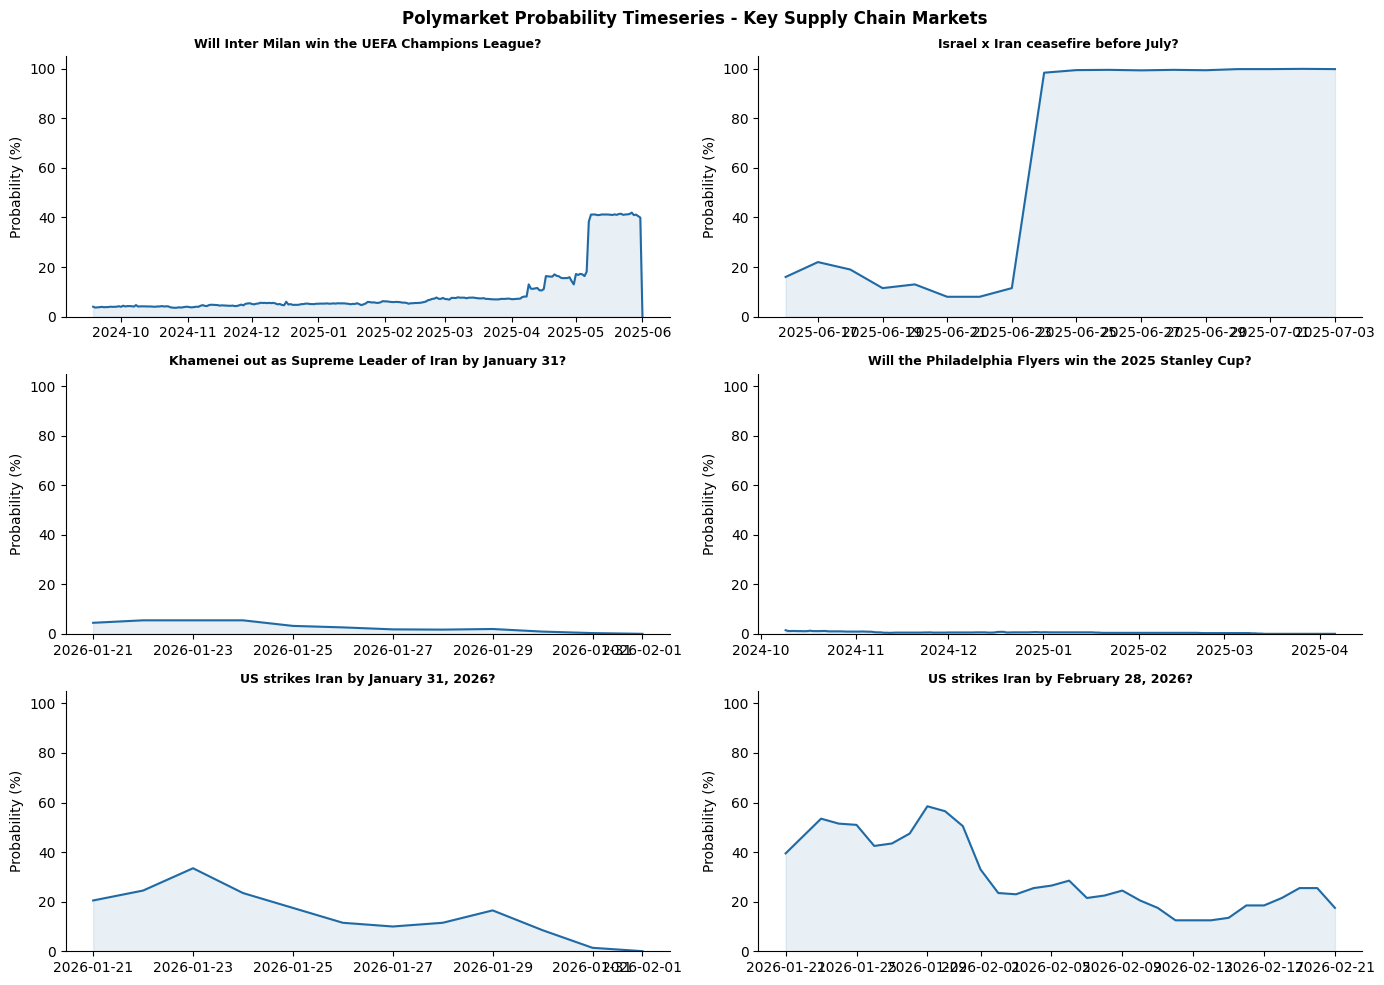

In [21]:
# Plot probability curves for first 6 markets with data
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()
plotted = 0
for mid, df in list(timeseries.items())[:6]:
    ax = axes[plotted]
    df_plot = df.copy()
    df_plot['date'] = pd.to_datetime(df_plot['date'])
    ax.plot(df_plot['date'], df_plot['probability'] * 100, color='#1f6aa5', linewidth=1.5)
    ax.fill_between(df_plot['date'], 0, df_plot['probability'] * 100,
                    alpha=0.1, color='#1f6aa5')
    title = df['market_title'].iloc[0] if 'market_title' in df.columns else mid
    ax.set_title(title[:55], fontsize=9, fontweight="bold")
    ax.set_ylabel('Probability (%)')
    ax.set_ylim(0, 105)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    plotted += 1

plt.suptitle('Polymarket Probability Timeseries - Key Supply Chain Markets',
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig('../output/figures/polymarket_timeseries_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: Fetch freight index data

In [22]:
from src.freight.scraper import fetch_all_freight_indexes, print_download_instructions
from src.freight.normalize import prepare_freight_panel

print_download_instructions()
freight_raw = fetch_all_freight_indexes(use_synthetic_fallback=True)
print(f'Loaded freight indexes: {list(freight_raw.keys())}')

INFO:src.freight.scraper:Fetching freight index: BDI
INFO:src.freight.scraper:Loaded 522 rows from data\freight\bdi.csv
INFO:src.freight.scraper:  → 522 observations for BDI
INFO:src.freight.scraper:Fetching freight index: FBX_GLOBAL
INFO:src.freight.scraper:Loaded 27 WCI rows for FBX_GLOBAL from data\freight\fbx_global.csv
INFO:src.freight.scraper:  → 27 observations for FBX_GLOBAL
INFO:src.freight.scraper:Fetching freight index: FBX01



FREIGHT DATA MANUAL DOWNLOAD INSTRUCTIONS

Place CSV files in: C:\Users\kekoi\Projects\operations_research\polymarket-scm-intel\notebooks\data\freight


──────────────────────────────────────────────────
Index: Baltic Dry Index (BDI)
Filename: bdi.csv
Source: Baltic Exchange
URL: https://tradingeconomics.com/commodity/baltic
Expected columns: ['date', 'value']
Frequency: daily

──────────────────────────────────────────────────
Index: FBX Global Container Index (FBX_GLOBAL)
Filename: fbx_global.csv
Source: Freightos Baltic Exchange
URL: https://en.macromicro.me/series/17502/fbx-global-container-index-weekly
Expected columns: ['date', 'value']
Frequency: weekly

──────────────────────────────────────────────────
Index: FBX01 China/East Asia to US West Coast (FBX01)
Filename: fbx01.csv
Source: Freightos Baltic Exchange
URL: https://www.freightos.com/freight-resources/fbx-freightos-baltic-exchange-index/
Expected columns: ['date', 'value']
Frequency: weekly

─────────────────────────────

INFO:src.freight.scraper:Extracted FBX01 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX01
INFO:src.freight.scraper:Fetching freight index: FBX03
INFO:src.freight.scraper:Extracted FBX03 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX03
INFO:src.freight.scraper:Fetching freight index: FBX11
INFO:src.freight.scraper:Extracted FBX11 (27 rows) from WCI multi-lane file (fbx_global.csv).
INFO:src.freight.scraper:  → 27 observations for FBX11


Loaded freight indexes: ['BDI', 'FBX_GLOBAL', 'FBX01', 'FBX03', 'FBX11']


In [23]:
freight_processed = prepare_freight_panel(freight_raw)

INFO:src.freight.normalize:Normalising freight index: BDI


INFO:src.freight.normalize:  BDI: 761 daily observations from 2024-01-22 to 2026-02-20
INFO:src.freight.normalize:Normalising freight index: FBX_GLOBAL
INFO:src.freight.normalize:  FBX_GLOBAL: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX01
INFO:src.freight.normalize:  FBX01: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX03
INFO:src.freight.normalize:  FBX03: 372 daily observations from 2025-02-13 to 2026-02-19
INFO:src.freight.normalize:Normalising freight index: FBX11
INFO:src.freight.normalize:  FBX11: 372 daily observations from 2025-02-13 to 2026-02-19


## Step 5: Visualize freight data

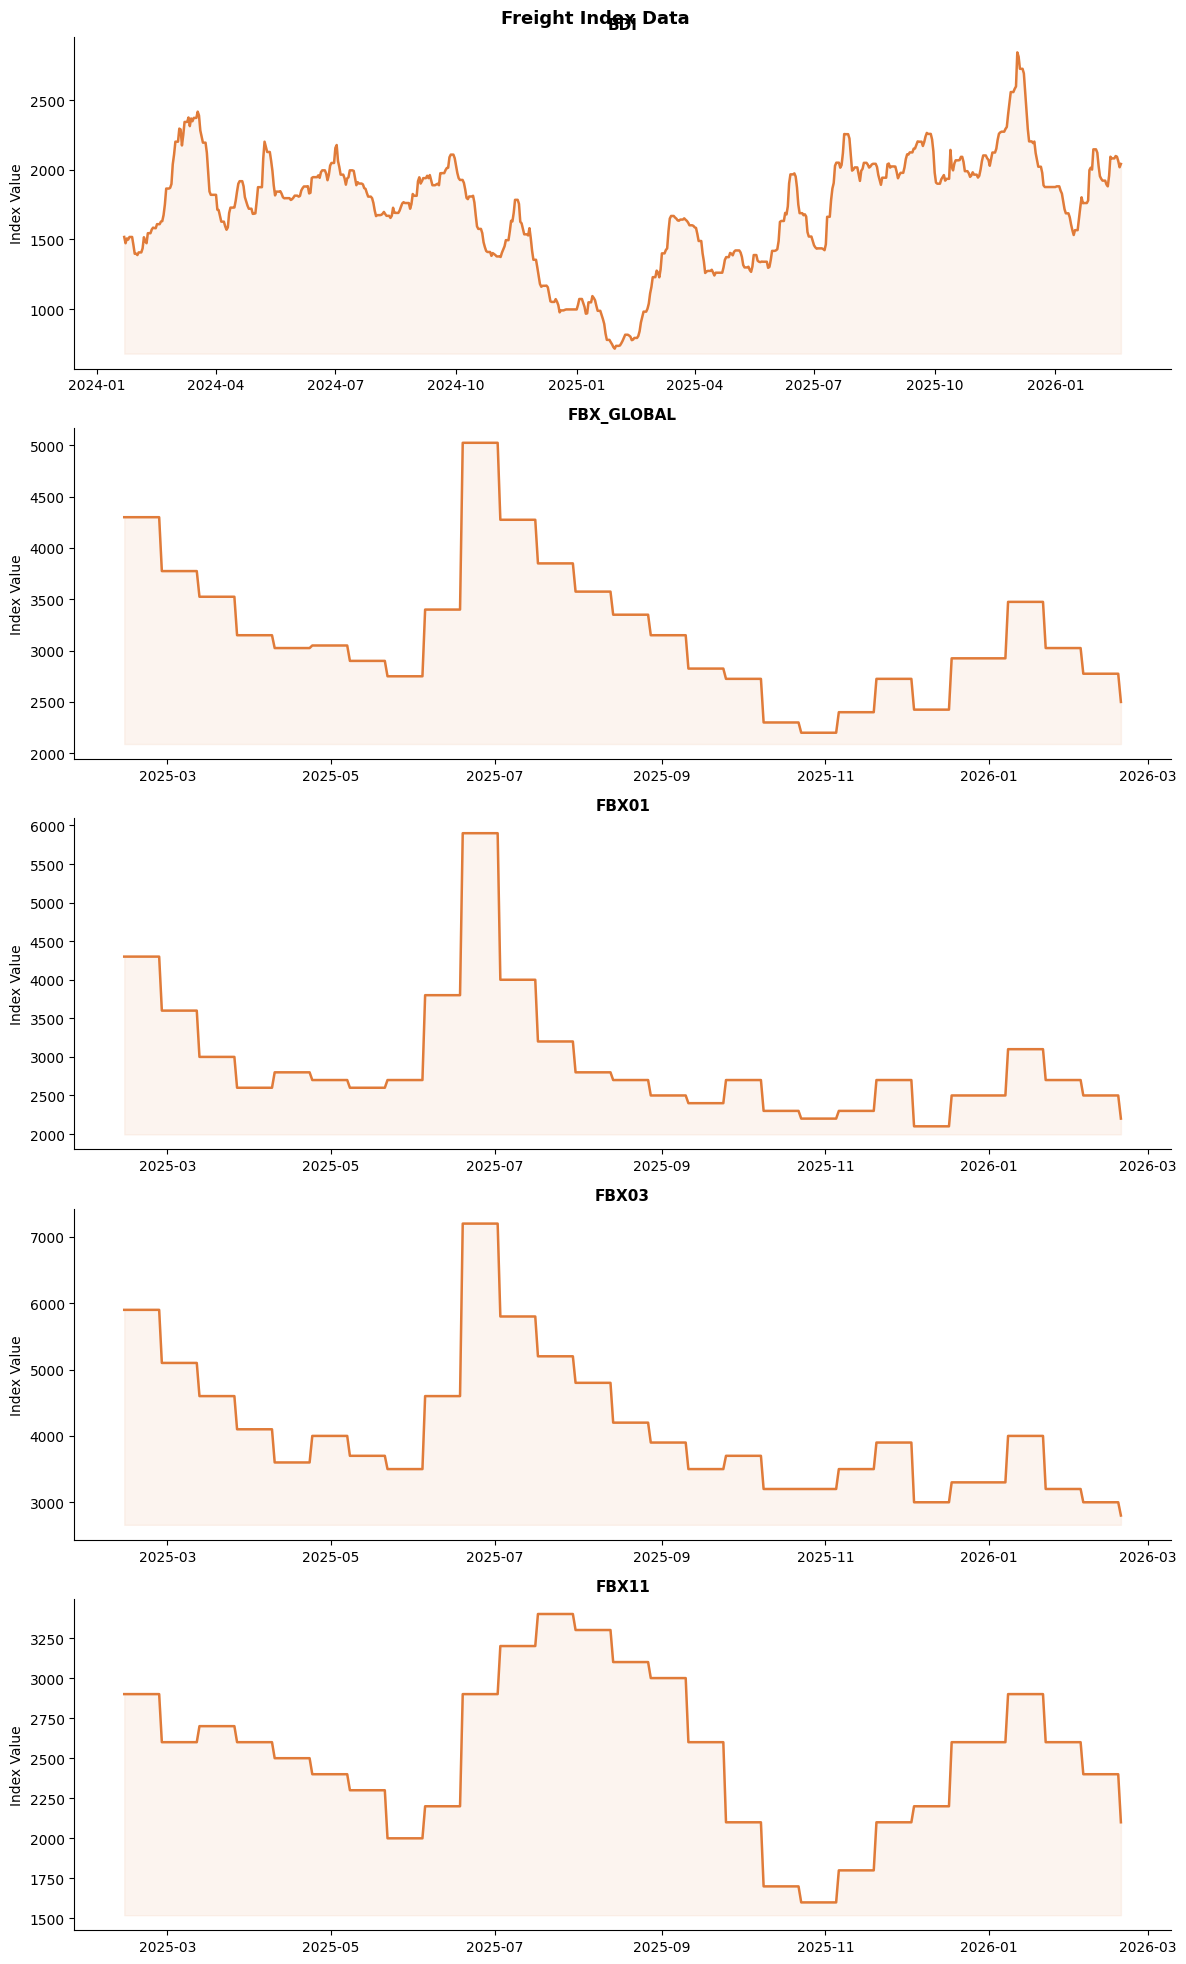

In [24]:
fig, axes = plt.subplots(len(freight_processed), 1,
                         figsize=(12, 4 * len(freight_processed)))
if len(freight_processed) == 1:
    axes = [axes]
for ax, (name, df) in zip(axes, freight_processed.items()):
    df_plot = df.copy()
    df_plot['date'] = pd.to_datetime(df_plot['date'])
    ax.plot(df_plot['date'], df_plot['value'], color='#e07b39', linewidth=1.8)
    ax.fill_between(df_plot['date'], df_plot['value'].min() * 0.95,
                    df_plot['value'], alpha=0.08, color='#e07b39')
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_ylabel('Index Value')
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
plt.suptitle('Freight Index Data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/figures/freight_indexes.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary
Data collection complete. Proceed to 03_analysis.ipynb.